# Inspect Time Series Data

Author: Pete King

This notebook reads the data gathered from the FRED API and Yahoo Finance into Pandas and inspects each time series -- a simple exercise in getting more familiar with the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt

import data_prep as dp

Lets inspect the data we pulled from Yahoo Finance

In [2]:
yfi_df = pd.read_csv('yfinance_data.csv', index_col='date')
yfi_df.head()

,BIL,BND,GLD,HYG_x,IEF,IWM,LQD_x,QQQ,SPY,TIP,...,NG=F,SHY,TLT_y,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
1927-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN
1928-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.760000,NaN,NaN,NaN,NaN,NaN
1928-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.719999,NaN,NaN,NaN,NaN,NaN
1928-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.549999,NaN,NaN,NaN,NaN,NaN
1928-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN


In [3]:
yfi_df.tail()

,BIL,BND,GLD,HYG_x,IEF,IWM,LQD_x,QQQ,SPY,TIP,...,NG=F,SHY,TLT_y,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
date,,,,,,,,,,,,,,,,,,,,,
2026-03-30,91.375999,73.230545,414.579987,78.429619,94.953560,239.610001,107.866783,558.280029,631.969971,110.349998,...,2.887,82.253212,86.434639,10128.000000,6343.720215,24750.789062,108.330002,4.342,30.610001,33.259998
2026-03-31,91.375999,73.389999,430.290009,79.175995,95.123001,248.000000,108.543999,577.179993,650.340027,110.360001,...,2.884,82.322998,86.345001,10176.500000,6528.520020,24788.140625,96.050003,4.311,25.250000,28.240000
2026-04-01,91.400002,73.419998,437.820007,79.370003,95.040001,249.559998,108.660004,584.309998,655.239990,110.360001,...,2.819,82.320000,86.260002,10364.799805,6575.319824,25294.029297,90.190002,4.319,24.540001,27.559999
2026-04-02,91.419998,73.580002,429.410004,79.559998,95.260002,251.289993,109.120003,584.979980,655.830017,110.809998,...,2.800,82.360001,86.790001,10436.299805,6582.689941,25116.529297,84.410004,4.313,23.870001,27.040001
2026-04-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81.777802,NaN,NaN,NaN


We can see visually roughly how far our data goes back for each series by looking for missing values (shown as white gaps in the image below).

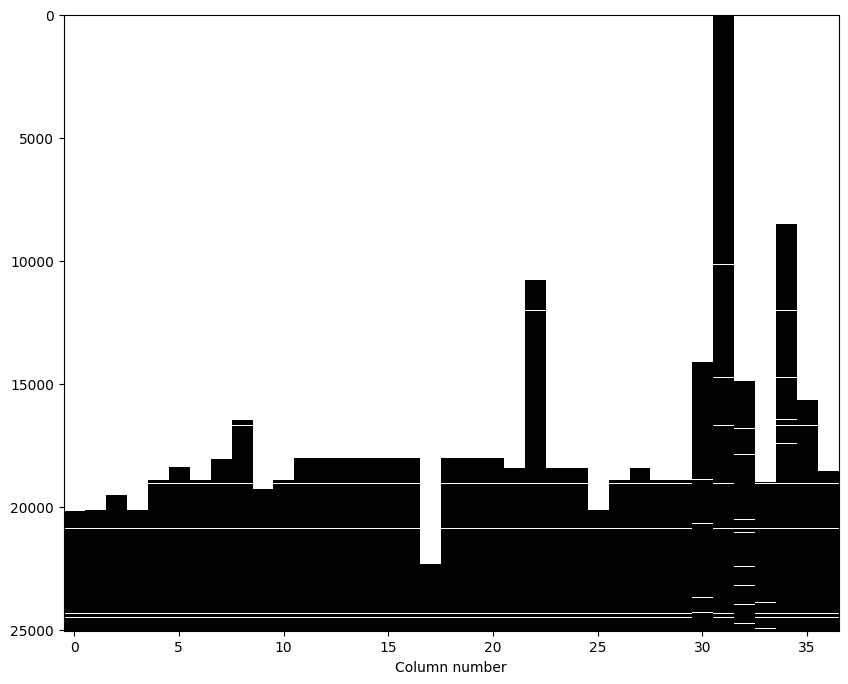

In [4]:
dp.view_nan(yfi_df);

In [5]:
for col_name in yfi_df.columns:
    print(yfi_df[col_name].dropna().head(1))

date
2007-05-30    71.212784
Name: BIL, dtype: float64
date
2007-04-10    41.497292
Name: BND, dtype: float64
date
2004-11-18    44.380001
Name: GLD, dtype: float64
date
2007-04-11    32.021988
Name: HYG_x, dtype: float64
date
2002-07-30    40.824837
Name: IEF, dtype: float64
date
2000-05-26    32.668125
Name: IWM, dtype: float64
date
2002-07-30    37.103703
Name: LQD_x, dtype: float64
date
1999-03-10    43.074337
Name: QQQ, dtype: float64
date
1993-01-29    24.175377
Name: SPY, dtype: float64
date
2003-12-05    51.016987
Name: TIP, dtype: float64
date
2002-07-30    36.24284
Name: TLT_x, dtype: float64
date
1998-12-22    5.718042
Name: XLB, dtype: float64
date
1998-12-22    5.73663
Name: XLE, dtype: float64
date
1998-12-22    11.163459
Name: XLF, dtype: float64
date
1998-12-22    14.432097
Name: XLI, dtype: float64
date
1998-12-22    11.923307
Name: XLK, dtype: float64
date
1998-12-22    13.986031
Name: XLP, dtype: float64
date
2015-10-08    21.044125
Name: XLRE, dtype: float64
date
19

Most of the ETFs go back to at least 2002, except for XLRE which starts in 2015.  Dropping XLRE will give us a much longer history to work with.

Now lets take a look at the data we pulled from the FRED API.

In [6]:
fred_df = pd.read_csv('fred_data.csv', index_col='date')
fred_df.head()

,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,unemployment_rate,...,female_unemployment_rate,average_duration_of_unemployment,one_month_yield,three_month_yield,six_month_yield,one_year_yield,two_year_yield,five_year_yield,ten_year_yield,thirty_year_yield
date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1947-01-01,243.164,2182.681,NaN,5.352,21.48,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
fred_df.tail()

,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,unemployment_rate,...,female_unemployment_rate,average_duration_of_unemployment,one_month_yield,three_month_yield,six_month_yield,one_year_yield,two_year_yield,five_year_yield,ten_year_yield,thirty_year_yield
date,,,,,,,,,,,,,,,,,,,,,
2026-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.74,3.71,3.73,3.71,3.82,3.97,4.35,4.91
2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.74,3.70,3.72,3.68,3.79,3.92,4.30,4.88
2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.74,3.70,3.72,3.68,3.81,3.97,4.33,4.91
2026-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.72,3.70,3.72,3.68,3.79,3.94,4.31,4.88


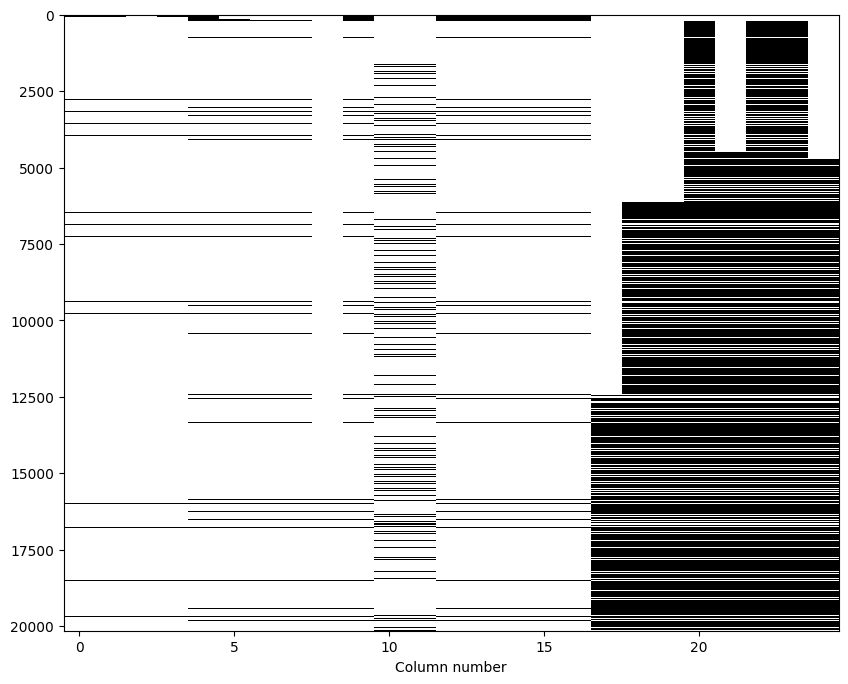

In [8]:
dp.view_nan(fred_df);

In [9]:
for col_name in fred_df.columns:
    print(fred_df[col_name].dropna().head(1))

date
1947-01-01    243.164
Name: nominal_GDP, dtype: float64
date
1947-01-01    2182.681
Name: real_GDP, dtype: float64
date
1966-01-01    40.33999
Name: debt_to_GDP, dtype: float64
date
1947-01-01    5.352
Name: debt_interest, dtype: float64
date
1947-01-01    21.48
Name: consumer_price_index, dtype: float64
date
1957-01-01    28.5
Name: core_PCI, dtype: float64
date
1959-01-01    15.164
Name: personal_consumption_expenditure, dtype: float64
date
1959-01-01    15.501
Name: core_PCE, dtype: float64
date
2009-11-01    100.2
Name: producer_price_index, dtype: float64
date
1948-01-01    3.4
Name: unemployment_rate, dtype: float64
date
1967-01-07    208000.0
Name: initial_jobless_claims, dtype: float64
date
1967-01-07    1134000.0
Name: continued_jobless_claims, dtype: float64
date
1948-01-01    8.5
Name: teenager_unemployment_rate, dtype: float64
date
1948-01-01    3.0
Name: adult_unemployment_rate, dtype: float64
date
1948-01-01    3.4
Name: male_unemployment_rate, dtype: float64
date
19

This data goes back quite a lot further, but here we have different frequency time series (quarterly, monthly, weekly, and daily).  The result is an overall sparse dataset for most of the time series.  The easy option would be to forward-fill the missing data.  The MIxed DAta Sampling (MIDAS) technique from econometrics presents an alternate way to deal with mixed frequency data, but implementation may be complicated.